In [1]:
import math

MIN_SCORE = 1
MAX_SCORE = 5
RETENTION_THRESHOLD = 0.3
LOW_UNDERSTANDING = 1 / 3
MAX_BASE_RETENTION = 0.99


def normalise(score):
    return (score - MIN_SCORE) / (MAX_SCORE - MIN_SCORE)


def calculate_recommendation(
    current_understanding,
    average_understanding,
    number_of_reviews,
    days_since_last_review,
):
    # 1. Adjusted understanding
    if current_understanding == 0:
        adjusted_understanding = average_understanding
    else:
        history_weight = min(number_of_reviews, 10)

        if history_weight == 0:
            adjusted_understanding = current_understanding
        else:
            adjusted_understanding = (
                history_weight * average_understanding
                + 2 * current_understanding
            ) / (history_weight + 2)

    # 2. Understanding strength
    understanding_score = max(
        0.0,
        min(normalise(adjusted_understanding), 1.0)
    )

    base_retention = max(
        0.01,
        min(understanding_score, MAX_BASE_RETENTION)
    )

    # 3. Review stability
    stability = number_of_reviews / (number_of_reviews + 5)

    # 4. Effective half-life
    understanding_factor = 0.5 + understanding_score
    stability_factor = 1 + stability

    half_life = (
        3
        + 12 * understanding_factor * stability_factor
    )

    # 5. Retention
    retention = 0.5 ** (
        days_since_last_review / half_life
    )

    # 6. Gap and forgetting risk
    understanding_gap = 1 - understanding_score
    forgetting_risk = 1 - retention

    # 7. Priority
    priority = (
        0.6 * understanding_gap
        + 0.4 * forgetting_risk
    )

    # 8. Recommendation
    if understanding_score < LOW_UNDERSTANDING:
        reason = "understanding"
        recommendation = "REVIEW - improve understanding"

    elif retention < RETENTION_THRESHOLD:
        reason = "retention"
        recommendation = "REVIEW - retention is low"

    else:
        reason = "ok"
        recommendation = "NOT RECOMMENDED"

    # 9. Due date
    if retention <= RETENTION_THRESHOLD:
        days_until_due = 0.0
    else:
        days_to_threshold = (
            half_life
            * math.log(RETENTION_THRESHOLD)
            / math.log(0.5)
        )

        days_until_due = (
            days_to_threshold - days_since_last_review
        )

    if reason == "understanding":
        days_until_due = min(days_until_due, 0.0)

    return {
        "adjusted_understanding": adjusted_understanding,
        "base_retention": base_retention,
        "retention": retention,
        "stability": stability,
        "half_life": half_life,
        "understanding_gap": understanding_gap,
        "forgetting_risk": forgetting_risk,
        "priority": priority,
        "recommendation": recommendation,
        "reason": reason,
        "days_until_due": days_until_due,
    }


In [2]:
result = calculate_recommendation(
    current_understanding=3,
    average_understanding=3.5,
    number_of_reviews=4,
    days_since_last_review=7,
)

result


{'adjusted_understanding': 3.3333333333333335,
 'base_retention': 0.5833333333333334,
 'retention': 0.8002770425809654,
 'stability': 0.4444444444444444,
 'half_life': 21.77777777777778,
 'understanding_gap': 0.41666666666666663,
 'forgetting_risk': 0.19972295741903456,
 'priority': 0.3298891829676138,
 'recommendation': 'NOT RECOMMENDED',
 'reason': 'ok',
 'days_until_due': 30.827250717397384}

In [3]:
test_cases = [
    {
        "name": "New / poor understanding",
        "current_understanding": 1,
        "average_understanding": 1,
        "number_of_reviews": 0,
        "days_since_last_review": 0,
    },
    {
        "name": "Weak understanding",
        "current_understanding": 2,
        "average_understanding": 2,
        "number_of_reviews": 1,
        "days_since_last_review": 2,
    },
    {
        "name": "Medium understanding",
        "current_understanding": 3,
        "average_understanding": 3,
        "number_of_reviews": 3,
        "days_since_last_review": 7,
    },
    {
        "name": "Strong understanding",
        "current_understanding": 4,
        "average_understanding": 4,
        "number_of_reviews": 5,
        "days_since_last_review": 14,
    },
    {
        "name": "Very strong understanding",
        "current_understanding": 5,
        "average_understanding": 5,
        "number_of_reviews": 10,
        "days_since_last_review": 20,
    },
    {
        "name": "Strong but long overdue",
        "current_understanding": 4,
        "average_understanding": 4,
        "number_of_reviews": 5,
        "days_since_last_review": 100,
    },
]

for case in test_cases:
    result = calculate_recommendation(
        case["current_understanding"],
        case["average_understanding"],
        case["number_of_reviews"],
        case["days_since_last_review"],
    )

    print(f"\n{case['name']}")
    print(f"  adjusted understanding: {result['adjusted_understanding']:.3f}")
    print(f"  retention:              {result['retention']:.3f}")
    print(f"  half-life:              {result['half_life']:.3f} days")
    print(f"  priority:               {result['priority']:.3f}")
    print(f"  recommendation:         {result['recommendation']}")
    print(f"  reason:                 {result['reason']}")
    print(f"  days until due:         {result['days_until_due']:.2f}")



New / poor understanding
  adjusted understanding: 1.000
  retention:              1.000
  half-life:              9.000 days
  priority:               0.600
  recommendation:         REVIEW - improve understanding
  reason:                 understanding
  days until due:         0.00

Weak understanding
  adjusted understanding: 2.000
  retention:              0.902
  half-life:              13.500 days
  priority:               0.489
  recommendation:         REVIEW - improve understanding
  reason:                 understanding
  days until due:         0.00

Medium understanding
  adjusted understanding: 3.000
  retention:              0.780
  half-life:              19.500 days
  priority:               0.388
  recommendation:         NOT RECOMMENDED
  reason:                 ok
  days until due:         26.87

Strong understanding
  adjusted understanding: 4.000
  retention:              0.683
  half-life:              25.500 days
  priority:               0.277
  recommendation

In [4]:
def test_engine_invariants():
    for understanding in range(1, 6):
        for average in range(1, 6):
            for reviews in [0, 1, 3, 5, 10, 20]:
                for days in [0, 1, 7, 30, 100]:

                    r = calculate_recommendation(
                        current_understanding=understanding,
                        average_understanding=average,
                        number_of_reviews=reviews,
                        days_since_last_review=days,
                    )

                    # Scores should be bounded
                    assert 0 <= r["understanding_gap"] <= 1
                    assert 0 <= r["forgetting_risk"] <= 1
                    assert 0 <= r["retention"] <= 1
                    assert 0 <= r["priority"] <= 1

                    # Stability should be bounded
                    assert 0 <= r["stability"] < 1

                    # Half-life should always be positive
                    assert r["half_life"] > 0

                    # Retention at day 0 should be 1
                    if days == 0:
                        assert math.isclose(
                            r["retention"],
                            1.0,
                            abs_tol=1e-12,
                        )

    print("All invariant tests passed.")


test_engine_invariants()


All invariant tests passed.


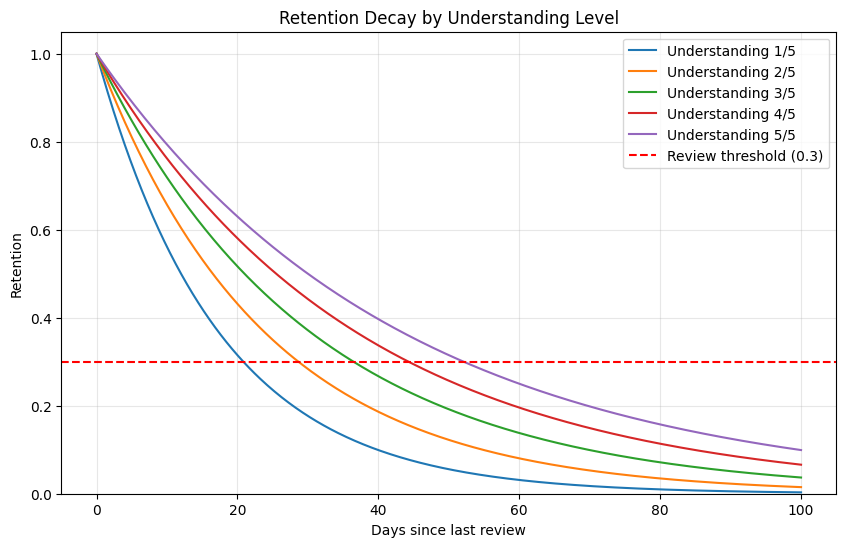

In [5]:
import numpy as np
import matplotlib.pyplot as plt

days = np.linspace(0, 100, 500)

understanding_levels = [1, 2, 3, 4, 5]
number_of_reviews = 5

plt.figure(figsize=(10, 6))

for understanding in understanding_levels:
    retentions = []

    for day in days:
        result = calculate_recommendation(
            current_understanding=understanding,
            average_understanding=understanding,
            number_of_reviews=number_of_reviews,
            days_since_last_review=day,
        )

        retentions.append(result["retention"])

    plt.plot(
        days,
        retentions,
        label=f"Understanding {understanding}/5"
    )

plt.axhline(
    RETENTION_THRESHOLD,
    color="red",
    linestyle="--",
    label=f"Review threshold ({RETENTION_THRESHOLD})"
)

plt.xlabel("Days since last review")
plt.ylabel("Retention")
plt.title("Retention Decay by Understanding Level")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


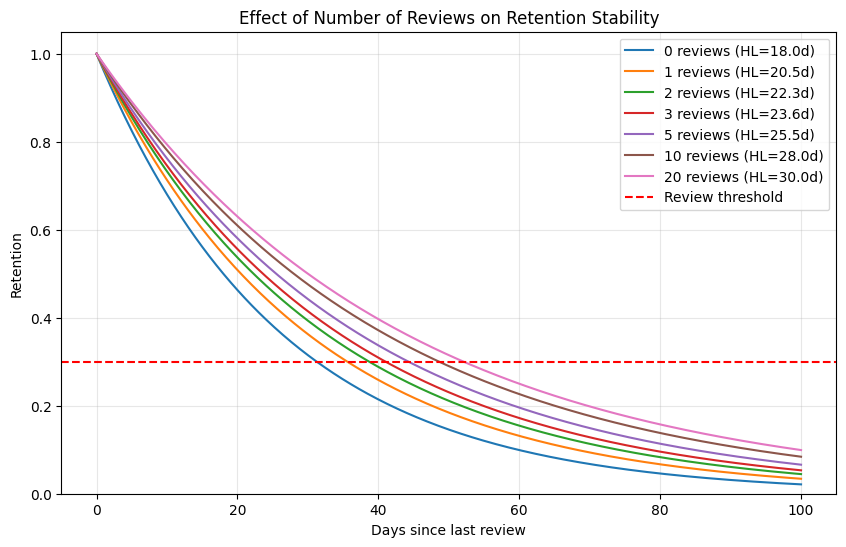

In [6]:
import numpy as np
import matplotlib.pyplot as plt

days = np.linspace(0, 100, 500)

review_counts = [0, 1, 2, 3, 5, 10, 20]
understanding = 4

plt.figure(figsize=(10, 6))

for reviews in review_counts:
    retentions = []
    half_life = None

    for day in days:
        result = calculate_recommendation(
            current_understanding=understanding,
            average_understanding=understanding,
            number_of_reviews=reviews,
            days_since_last_review=day,
        )

        retentions.append(result["retention"])
        half_life = result["half_life"]

    plt.plot(
        days,
        retentions,
        label=f"{reviews} reviews (HL={half_life:.1f}d)"
    )

plt.axhline(
    RETENTION_THRESHOLD,
    color="red",
    linestyle="--",
    label="Review threshold"
)

plt.xlabel("Days since last review")
plt.ylabel("Retention")
plt.title("Effect of Number of Reviews on Retention Stability")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [7]:
for reviews in [0, 1, 2, 3, 5, 10, 20, 50, 100]:
    result = calculate_recommendation(
        current_understanding=4,
        average_understanding=4,
        number_of_reviews=reviews,
        days_since_last_review=0,
    )

    print(
        f"Reviews: {reviews:3d} | "
        f"Stability: {result['stability']:.3f} | "
        f"Half-life: {result['half_life']:.2f} days"
    )


Reviews:   0 | Stability: 0.000 | Half-life: 18.00 days
Reviews:   1 | Stability: 0.167 | Half-life: 20.50 days
Reviews:   2 | Stability: 0.286 | Half-life: 22.29 days
Reviews:   3 | Stability: 0.375 | Half-life: 23.62 days
Reviews:   5 | Stability: 0.500 | Half-life: 25.50 days
Reviews:  10 | Stability: 0.667 | Half-life: 28.00 days
Reviews:  20 | Stability: 0.800 | Half-life: 30.00 days
Reviews:  50 | Stability: 0.909 | Half-life: 31.64 days
Reviews: 100 | Stability: 0.952 | Half-life: 32.29 days


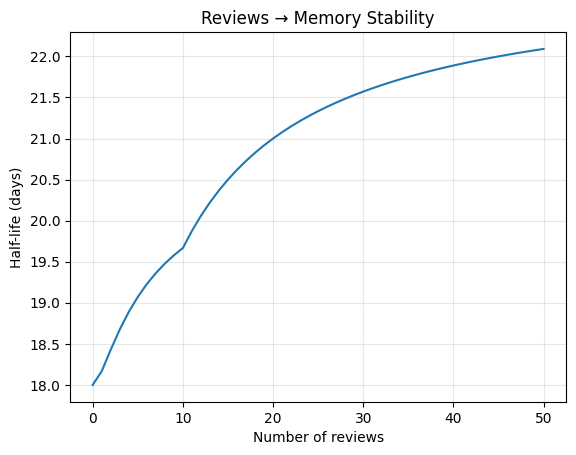

In [17]:
reviews = np.arange(0, 51)

half_lives = []

for n in reviews:
    r = calculate_recommendation(
        current_understanding=4,
        average_understanding=2,
        number_of_reviews=n,
        days_since_last_review=0,
    )
    half_lives.append(r["half_life"])

plt.plot(reviews, half_lives)
plt.xlabel("Number of reviews")
plt.ylabel("Half-life (days)")
plt.title("Reviews → Memory Stability")
plt.grid(alpha=0.3)
plt.show()


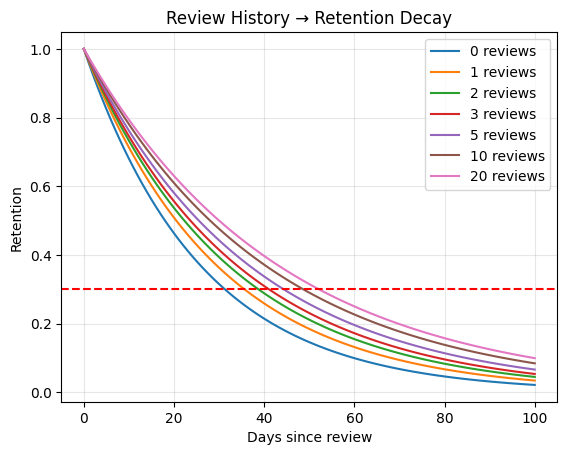

In [18]:
reviews = [0, 1, 2, 3, 5, 10, 20]
days = np.arange(0, 101)

for n in reviews:
    retention = []

    for d in days:
        r = calculate_recommendation(
            current_understanding=4,
            average_understanding=4,
            number_of_reviews=n,
            days_since_last_review=d,
        )
        retention.append(r["retention"])

    plt.plot(days, retention, label=f"{n} reviews")

plt.axhline(0.3, color="red", linestyle="--")
plt.xlabel("Days since review")
plt.ylabel("Retention")
plt.title("Review History → Retention Decay")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


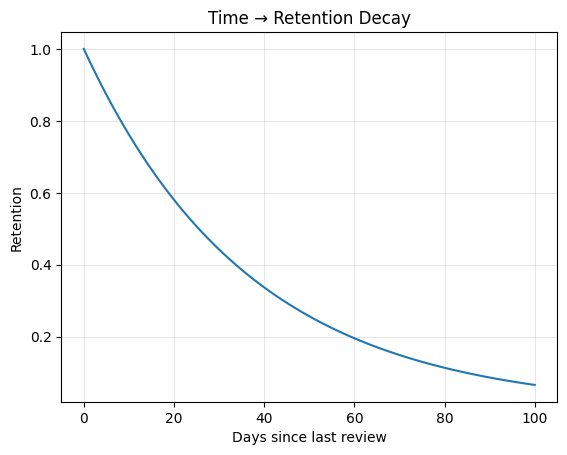

In [19]:
days = np.arange(0, 101)

retention = [
    calculate_recommendation(
        current_understanding=4,
        average_understanding=4,
        number_of_reviews=5,
        days_since_last_review=d,
    )["retention"]
    for d in days
]

plt.plot(days, retention)
plt.xlabel("Days since last review")
plt.ylabel("Retention")
plt.title("Time → Retention Decay")
plt.grid(alpha=0.3)
plt.show()


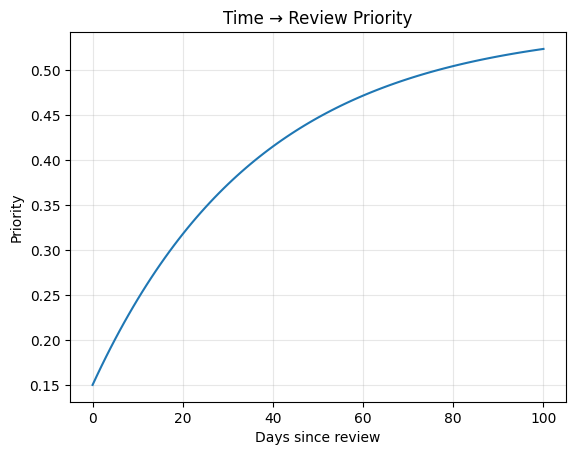

In [20]:
days = np.arange(0, 101)

priority = [
    calculate_recommendation(
        4, 4, 5, d
    )["priority"]
    for d in days
]

plt.plot(days, priority)
plt.xlabel("Days since review")
plt.ylabel("Priority")
plt.title("Time → Review Priority")
plt.grid(alpha=0.3)
plt.show()


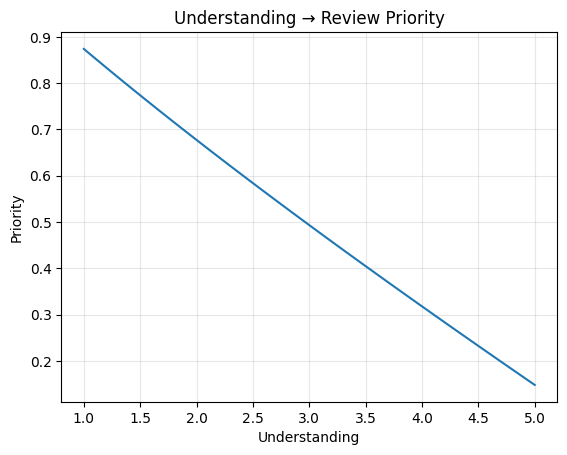

In [21]:
understanding = np.linspace(1, 5, 100)

priority = [
    calculate_recommendation(
        u, u, 5, 20
    )["priority"]
    for u in understanding
]

plt.plot(understanding, priority)
plt.xlabel("Understanding")
plt.ylabel("Priority")
plt.title("Understanding → Review Priority")
plt.grid(alpha=0.3)
plt.show()


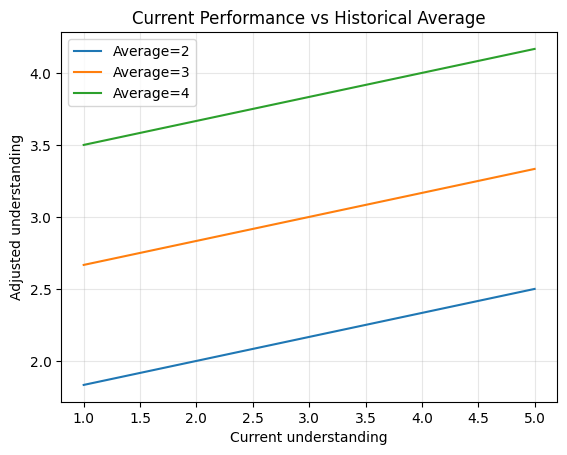

In [22]:
current = np.linspace(1, 5, 100)
averages = [2, 3, 4]

for avg in averages:
    adjusted = []

    for c in current:
        r = calculate_recommendation(
            current_understanding=c,
            average_understanding=avg,
            number_of_reviews=10,
            days_since_last_review=0,
        )
        adjusted.append(r["adjusted_understanding"])

    plt.plot(current, adjusted, label=f"Average={avg}")

plt.xlabel("Current understanding")
plt.ylabel("Adjusted understanding")
plt.title("Current Performance vs Historical Average")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


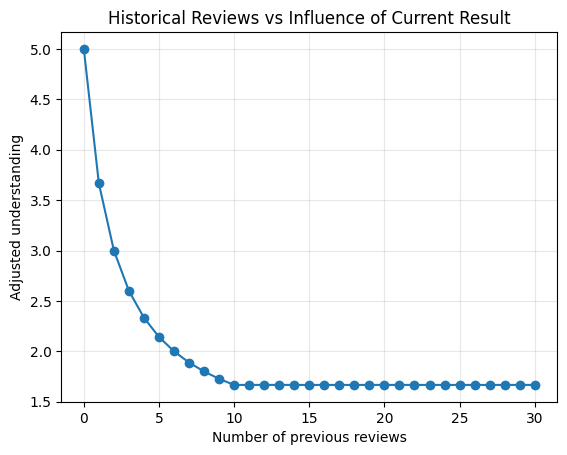

In [27]:
reviews = np.arange(0, 31)

adjusted = [
    calculate_recommendation(
        current_understanding=5,
        average_understanding=1,
        number_of_reviews=n,
        days_since_last_review=0,
    )["adjusted_understanding"]
    for n in reviews
]

plt.plot(reviews, adjusted, marker="o")
plt.xlabel("Number of previous reviews")
plt.ylabel("Adjusted understanding")
plt.title("Historical Reviews vs Influence of Current Result")
plt.grid(alpha=0.3)
plt.show()


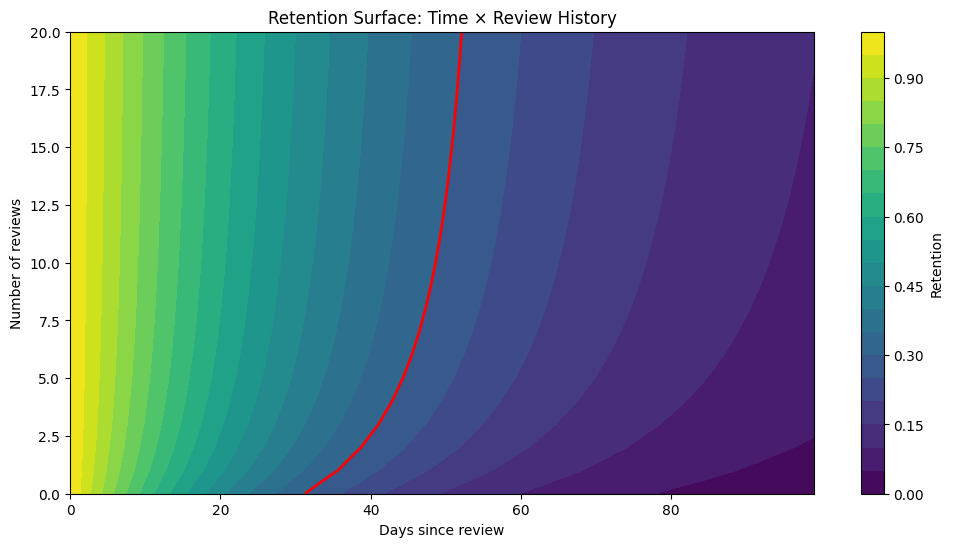

In [28]:
days = np.arange(0, 100)
reviews = np.arange(0, 21)

Z = np.zeros((len(reviews), len(days)))

for i, n in enumerate(reviews):
    for j, d in enumerate(days):
        r = calculate_recommendation(
            current_understanding=4,
            average_understanding=4,
            number_of_reviews=n,
            days_since_last_review=d,
        )

        Z[i, j] = r["retention"]

plt.figure(figsize=(12, 6))

plt.contourf(
    days,
    reviews,
    Z,
    levels=20,
    cmap="viridis"
)

plt.colorbar(label="Retention")

plt.contour(
    days,
    reviews,
    Z,
    levels=[RETENTION_THRESHOLD],
    colors="red",
    linewidths=2
)

plt.xlabel("Days since review")
plt.ylabel("Number of reviews")
plt.title("Retention Surface: Time × Review History")
plt.show()


In [29]:
def test_monotonic_relationships():
    # More days should never increase retention
    for reviews in [0, 1, 5, 10]:
        previous = 1.0

        for day in range(101):
            r = calculate_recommendation(4, 4, reviews, day)
            assert r["retention"] <= previous + 1e-12
            previous = r["retention"]

    # More reviews should never decrease half-life
    previous = 0

    for reviews in range(101):
        r = calculate_recommendation(4, 4, reviews, 0)
        assert r["half_life"] >= previous
        previous = r["half_life"]

    # More reviews should never decrease retention at a fixed time
    for day in [1, 7, 30, 60, 100]:
        previous = 0

        for reviews in range(101):
            r = calculate_recommendation(4, 4, reviews, day)
            assert r["retention"] >= previous - 1e-12
            previous = r["retention"]

    print("All monotonicity tests passed.")


test_monotonic_relationships()


All monotonicity tests passed.


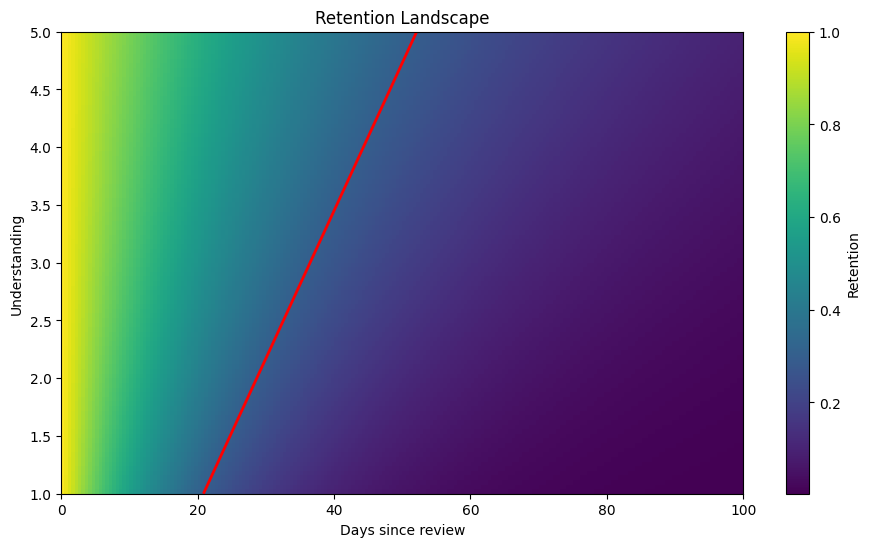

In [30]:
import numpy as np
import matplotlib.pyplot as plt

understandings = np.linspace(1, 5, 100)
days = np.linspace(0, 100, 200)

Z = np.zeros((len(understandings), len(days)))

for i, u in enumerate(understandings):
    for j, d in enumerate(days):
        Z[i, j] = calculate_recommendation(
            u, u, 5, d
        )["retention"]

plt.figure(figsize=(11, 6))

plt.imshow(
    Z,
    aspect="auto",
    origin="lower",
    extent=[days.min(), days.max(),
            understandings.min(), understandings.max()],
    cmap="viridis"
)

plt.colorbar(label="Retention")

plt.contour(
    days,
    understandings,
    Z,
    levels=[0.3],
    colors="red",
    linewidths=2
)

plt.xlabel("Days since review")
plt.ylabel("Understanding")
plt.title("Retention Landscape")

plt.show()


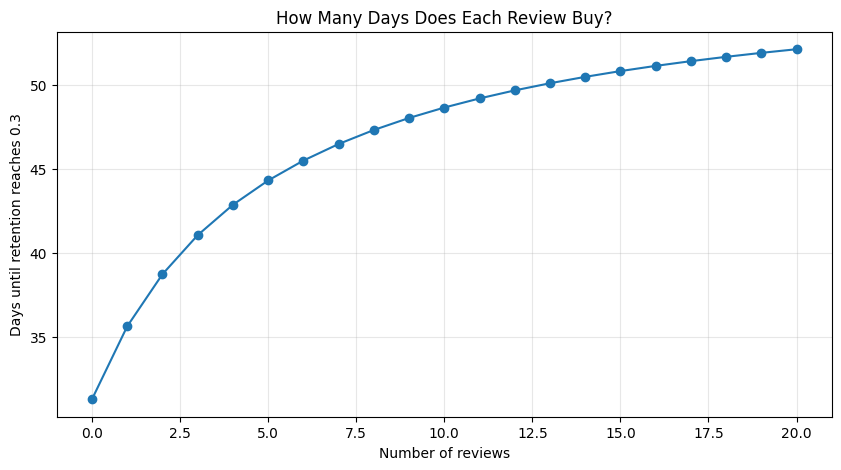

In [31]:
reviews = np.arange(0, 21)

days_to_threshold = []

for n in reviews:
    r = calculate_recommendation(
        4, 4, n, 0
    )

    half_life = r["half_life"]

    days_due = (
        half_life
        * np.log(RETENTION_THRESHOLD)
        / np.log(0.5)
    )

    days_to_threshold.append(days_due)

plt.figure(figsize=(10, 5))

plt.plot(
    reviews,
    days_to_threshold,
    marker="o"
)

plt.xlabel("Number of reviews")
plt.ylabel("Days until retention reaches 0.3")
plt.title("How Many Days Does Each Review Buy?")

plt.grid(alpha=0.3)
plt.show()


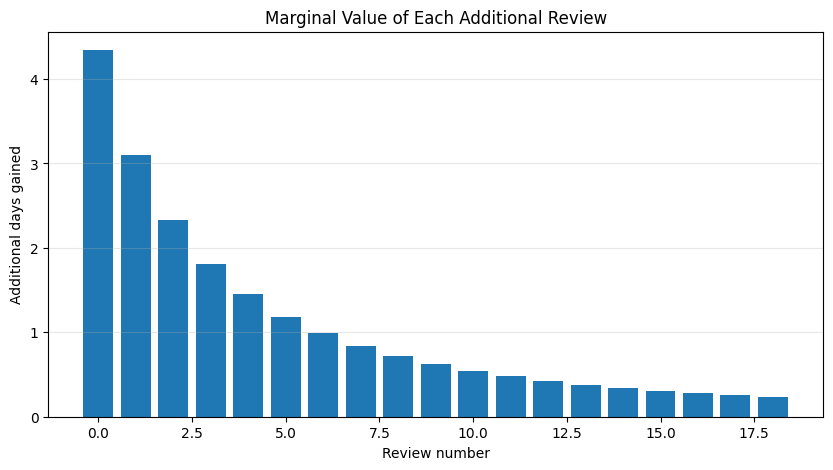

In [32]:
reviews = np.arange(0, 20)

due_days = []

for n in reviews:
    r = calculate_recommendation(4, 4, n, 0)

    due = (
        r["half_life"]
        * np.log(RETENTION_THRESHOLD)
        / np.log(0.5)
    )

    due_days.append(due)

marginal_gain = np.diff(due_days)

plt.figure(figsize=(10, 5))

plt.bar(
    reviews[:-1],
    marginal_gain
)

plt.xlabel("Review number")
plt.ylabel("Additional days gained")
plt.title("Marginal Value of Each Additional Review")

plt.grid(axis="y", alpha=0.3)
plt.show()


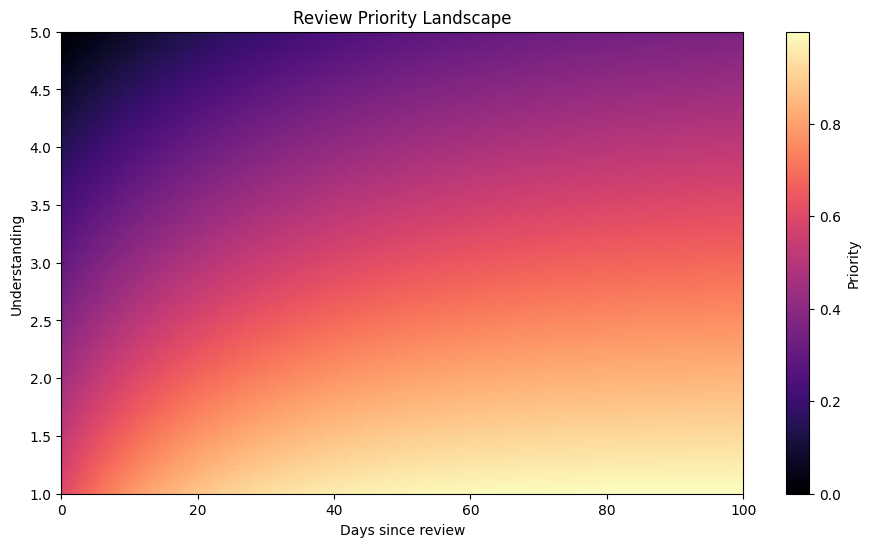

In [33]:
understandings = np.linspace(1, 5, 100)
days = np.linspace(0, 100, 200)

Z = np.zeros((len(understandings), len(days)))

for i, u in enumerate(understandings):
    for j, d in enumerate(days):

        r = calculate_recommendation(
            u, u, 5, d
        )

        Z[i, j] = r["priority"]

plt.figure(figsize=(11, 6))

plt.imshow(
    Z,
    aspect="auto",
    origin="lower",
    extent=[
        days.min(),
        days.max(),
        understandings.min(),
        understandings.max()
    ],
    cmap="magma"
)

plt.colorbar(label="Priority")

plt.xlabel("Days since review")
plt.ylabel("Understanding")
plt.title("Review Priority Landscape")

plt.show()


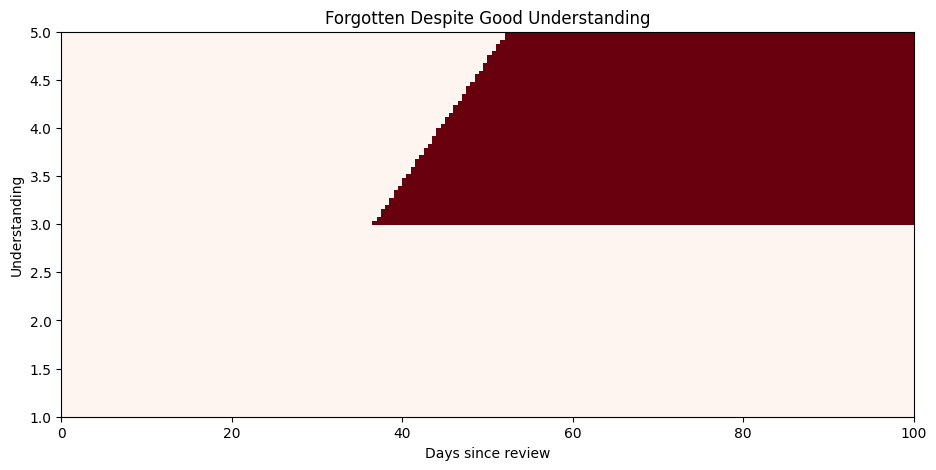

In [34]:
understandings = np.linspace(1, 5, 100)
days = np.linspace(0, 100, 200)

Z = np.zeros((len(understandings), len(days)))

for i, u in enumerate(understandings):
    for j, d in enumerate(days):

        r = calculate_recommendation(u, u, 5, d)

        Z[i, j] = (
            r["retention"] < RETENTION_THRESHOLD
            and u >= 3
        )

plt.figure(figsize=(11, 5))

plt.imshow(
    Z,
    aspect="auto",
    origin="lower",
    extent=[0, 100, 1, 5],
    cmap="Reds"
)

plt.xlabel("Days since review")
plt.ylabel("Understanding")
plt.title("Forgotten Despite Good Understanding")

plt.show()


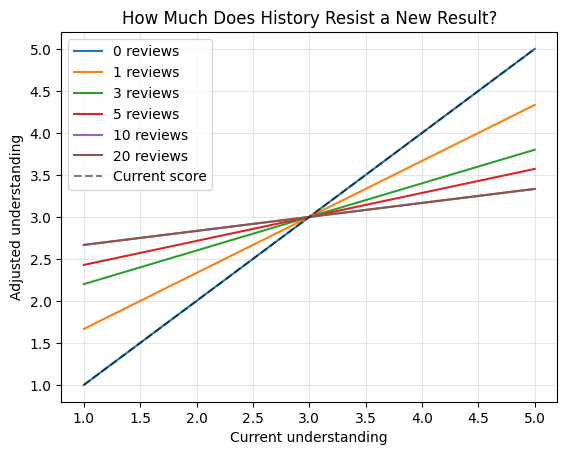

In [35]:
current = np.linspace(1, 5, 100)

for reviews in [0, 1, 3, 5, 10, 20]:

    adjusted = []

    for c in current:
        r = calculate_recommendation(
            c,
            3,
            reviews,
            0
        )

        adjusted.append(r["adjusted_understanding"])

    plt.plot(
        current,
        adjusted,
        label=f"{reviews} reviews"
    )

plt.plot(
    current,
    current,
    "k--",
    alpha=0.5,
    label="Current score"
)

plt.xlabel("Current understanding")
plt.ylabel("Adjusted understanding")
plt.title("How Much Does History Resist a New Result?")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


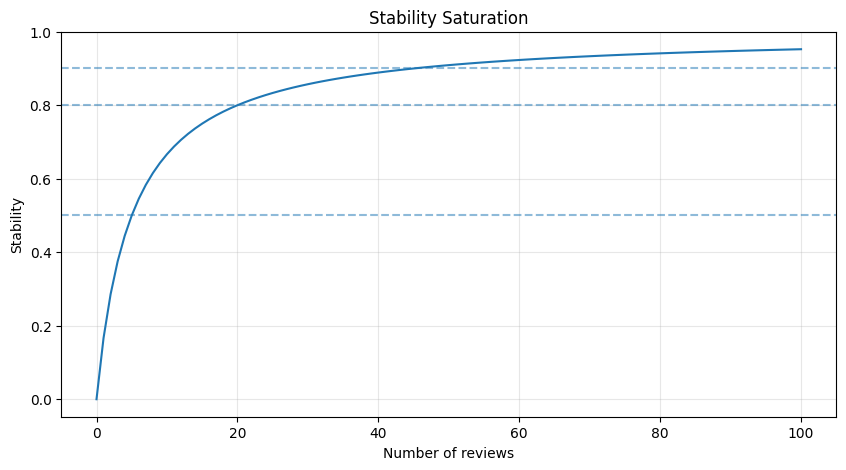

In [36]:
reviews = np.arange(0, 101)

stability = reviews / (reviews + 5)

plt.figure(figsize=(10, 5))

plt.plot(reviews, stability)

plt.axhline(0.5, linestyle="--", alpha=0.5)
plt.axhline(0.8, linestyle="--", alpha=0.5)
plt.axhline(0.9, linestyle="--", alpha=0.5)

plt.xlabel("Number of reviews")
plt.ylabel("Stability")
plt.title("Stability Saturation")

plt.grid(alpha=0.3)
plt.show()


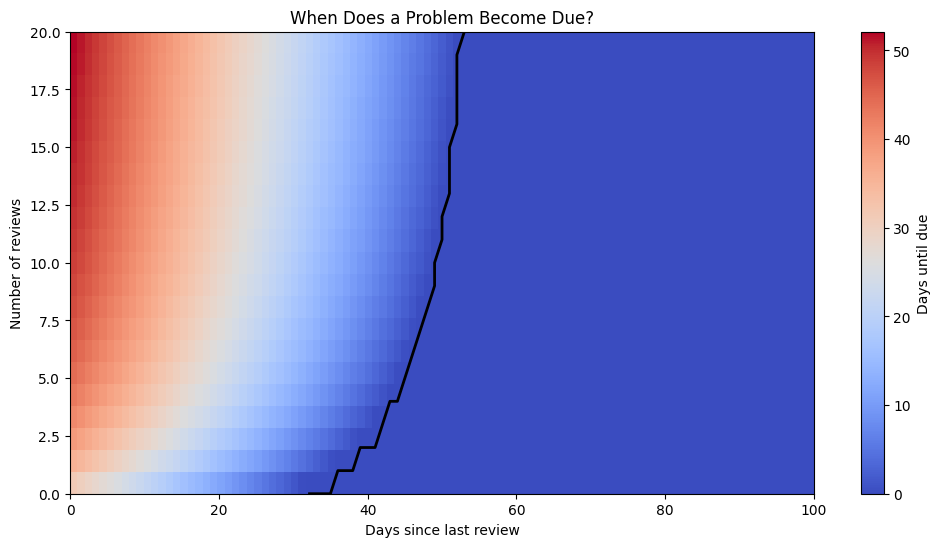

In [37]:
understanding = 4

reviews = np.arange(0, 21)
days_since = np.arange(0, 101)

Z = np.zeros((len(reviews), len(days_since)))

for i, n in enumerate(reviews):
    for j, d in enumerate(days_since):

        r = calculate_recommendation(
            understanding,
            understanding,
            n,
            d
        )

        Z[i, j] = r["days_until_due"]

plt.figure(figsize=(12, 6))

plt.imshow(
    Z,
    aspect="auto",
    origin="lower",
    extent=[
        days_since.min(),
        days_since.max(),
        reviews.min(),
        reviews.max()
    ],
    cmap="coolwarm"
)

plt.colorbar(label="Days until due")

plt.contour(
    days_since,
    reviews,
    Z,
    levels=[0],
    colors="black",
    linewidths=2
)

plt.xlabel("Days since last review")
plt.ylabel("Number of reviews")
plt.title("When Does a Problem Become Due?")

plt.show()


In [38]:
def sensitivity(base, parameter, delta):

    args = dict(
        current_understanding=4,
        average_understanding=4,
        number_of_reviews=5,
        days_since_last_review=20,
    )

    original = calculate_recommendation(**args)["priority"]

    args[parameter] += delta

    changed = calculate_recommendation(**args)["priority"]

    return changed - original


parameters = [
    "current_understanding",
    "average_understanding",
    "number_of_reviews",
    "days_since_last_review",
]

for p in parameters:

    if p in ["current_understanding", "average_understanding"]:
        delta = 0.1
    else:
        delta = 1

    print(
        p,
        sensitivity(None, p, delta)
    )

# Sign
# Negative → increasing that input decreases priority

# Positive → increasing that input increases priority

current_understanding -0.004920001189488432
average_understanding -0.012291344438844165
number_of_reviews -0.0033114633822070028
days_since_last_review 0.0062280793324227535


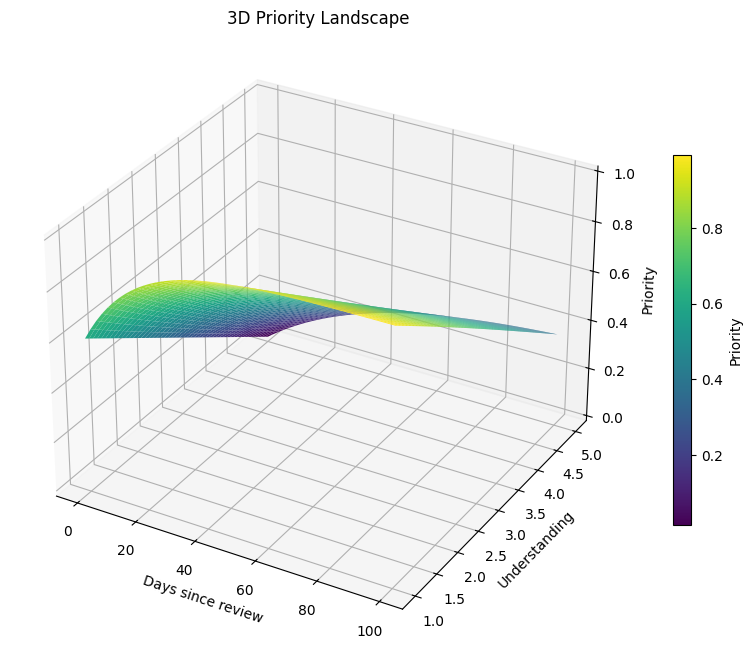

In [39]:
from mpl_toolkits.mplot3d import Axes3D

days = np.linspace(0, 100, 50)
understanding = np.linspace(1, 5, 50)

X, Y = np.meshgrid(days, understanding)

Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):

        r = calculate_recommendation(
            Y[i, j],
            Y[i, j],
            5,
            X[i, j]
        )

        Z[i, j] = r["priority"]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis"
)

ax.set_xlabel("Days since review")
ax.set_ylabel("Understanding")
ax.set_zlabel("Priority")

ax.set_title("3D Priority Landscape")

fig.colorbar(
    surface,
    shrink=0.6,
    label="Priority"
)

plt.show()
